# Large-Einstein-radius systems in RGB

Loads the rung 0 `v_2_1` dataset, keeps only the systems whose Einstein radius exceeds a
threshold (2.5" by default), and plots them as a grid of RGB composites.

In [12]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import make_lupton_rgb

# Open the dataset

Make sure to update the filepath in the block below!

In [13]:
h5_filepath = '/data2/bwedig/mejiro/roman_data_challenge_rung_0/06/roman_data_challenge_rung_0_v_2_1.h5'  # TODO update this path!
f = h5py.File(h5_filepath, 'r')

for key, value in f.attrs.items():
    print(f"{key}: {value}")

author: ['bwedig@marduk.physics.wustl.edu' 'username@host for calculation']
created: 2026_07_04-09_58_40_PM
dataset_version: 2.1
lenstronomy_version: ['1.13.3' 'lenstronomy version']
mejiro_version: ['3.0.0' 'mejiro version']
romanisim_version: ['0.13.0' 'romanisim version']
slsim_version: ['0.1.1' 'SLSim version']
stpsf_version: ['2.1.0' 'STPSF version']


In [14]:
uids = sorted(key.removeprefix('strong_lens_') for key in f['images'].keys())

# inspect the first system to see which bands are present
first_group = f['images'][f'strong_lens_{uids[0]}']
bands = sorted({key.split('_')[-1] for key in first_group.keys() if key.startswith('exposure_')})

print(f'{len(uids)} systems: {uids[0]} through {uids[-1]}')
print(f'Bands: {", ".join(bands)}')

11160 systems: 00000000 through 00011178
Bands: F106, F129, F158


# Filter on Einstein radius

The Einstein radius is stored as the `theta_e` attribute (in arcseconds) on each
`strong_lens` group; like all attributes in this file, it's a `(value, description)` pair
of strings, so it needs a cast to `float`.

In [15]:
theta_e_min = 2.5  # arcsec

theta_e = np.array([float(f['images'][f'strong_lens_{uid}'].attrs['theta_e'][0]) for uid in uids])

mask = theta_e > theta_e_min
selected_uids = [uid for uid, keep in zip(uids, mask) if keep]
selected_theta_e = theta_e[mask]

# sort by Einstein radius, largest first
order = np.argsort(selected_theta_e)[::-1]
selected_uids = [selected_uids[i] for i in order]
selected_theta_e = selected_theta_e[order]

print(f'{len(selected_uids)} of {len(uids)} systems have theta_E > {theta_e_min}"')
if len(selected_uids) > 0:
    print(f'Einstein radii range from {selected_theta_e.min():.2f}" to {selected_theta_e.max():.2f}"')

141 of 11160 systems have theta_E > 2.5"
Einstein radii range from 2.50" to 3.85"


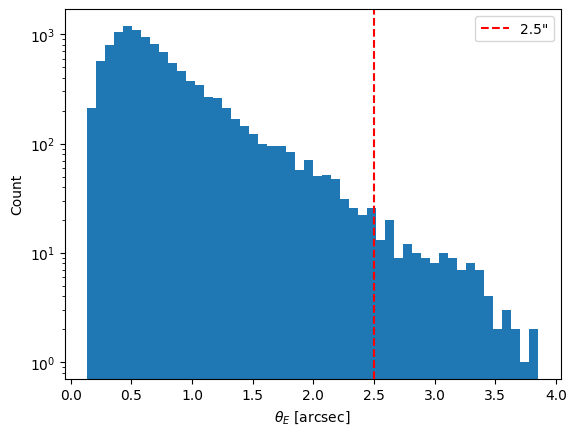

In [16]:
plt.hist(theta_e, bins=50)
plt.axvline(theta_e_min, color='red', linestyle='--', label=f'{theta_e_min}"')
plt.xlabel(r'$\theta_E$ [arcsec]')
plt.ylabel('Count')
plt.yscale('log')
plt.legend()
plt.show()

# Build the RGB composites

Each composite uses an arcsinh (Lupton) stretch across three filters. Adjust `stretch` and
`Q` to taste: larger `Q` brings out fainter features, larger `stretch` compresses the
bright end. Set `normalize_by_exposure_time` to `True` to convert counts to count rates
before compositing, which balances the channels if the bands weren't exposed for the same
length of time.

In [17]:
rgb_bands = ['F158', 'F129', 'F106']  # R, G, B
stretch = 1
Q = 5
normalize_by_exposure_time = False

missing = [band for band in rgb_bands if band not in bands]
assert not missing, f'Dataset is missing band(s) {missing}; available bands: {bands}'


def rgb_image(uid):
    channels = []
    for band in rgb_bands:
        dataset = f['images'][f'strong_lens_{uid}'][f'exposure_{uid}_{band}']
        data = dataset[()].astype(float)
        if normalize_by_exposure_time:
            data /= float(dataset.attrs['exposure_time'][0])
        channels.append(data)
    return make_lupton_rgb(*channels, stretch=stretch, Q=Q, minimum=np.min(channels))

# The grid

Panels are labeled with the Einstein radius in arcseconds. Cap the number of panels with
`max_panels` if the selection is larger than you want to plot.

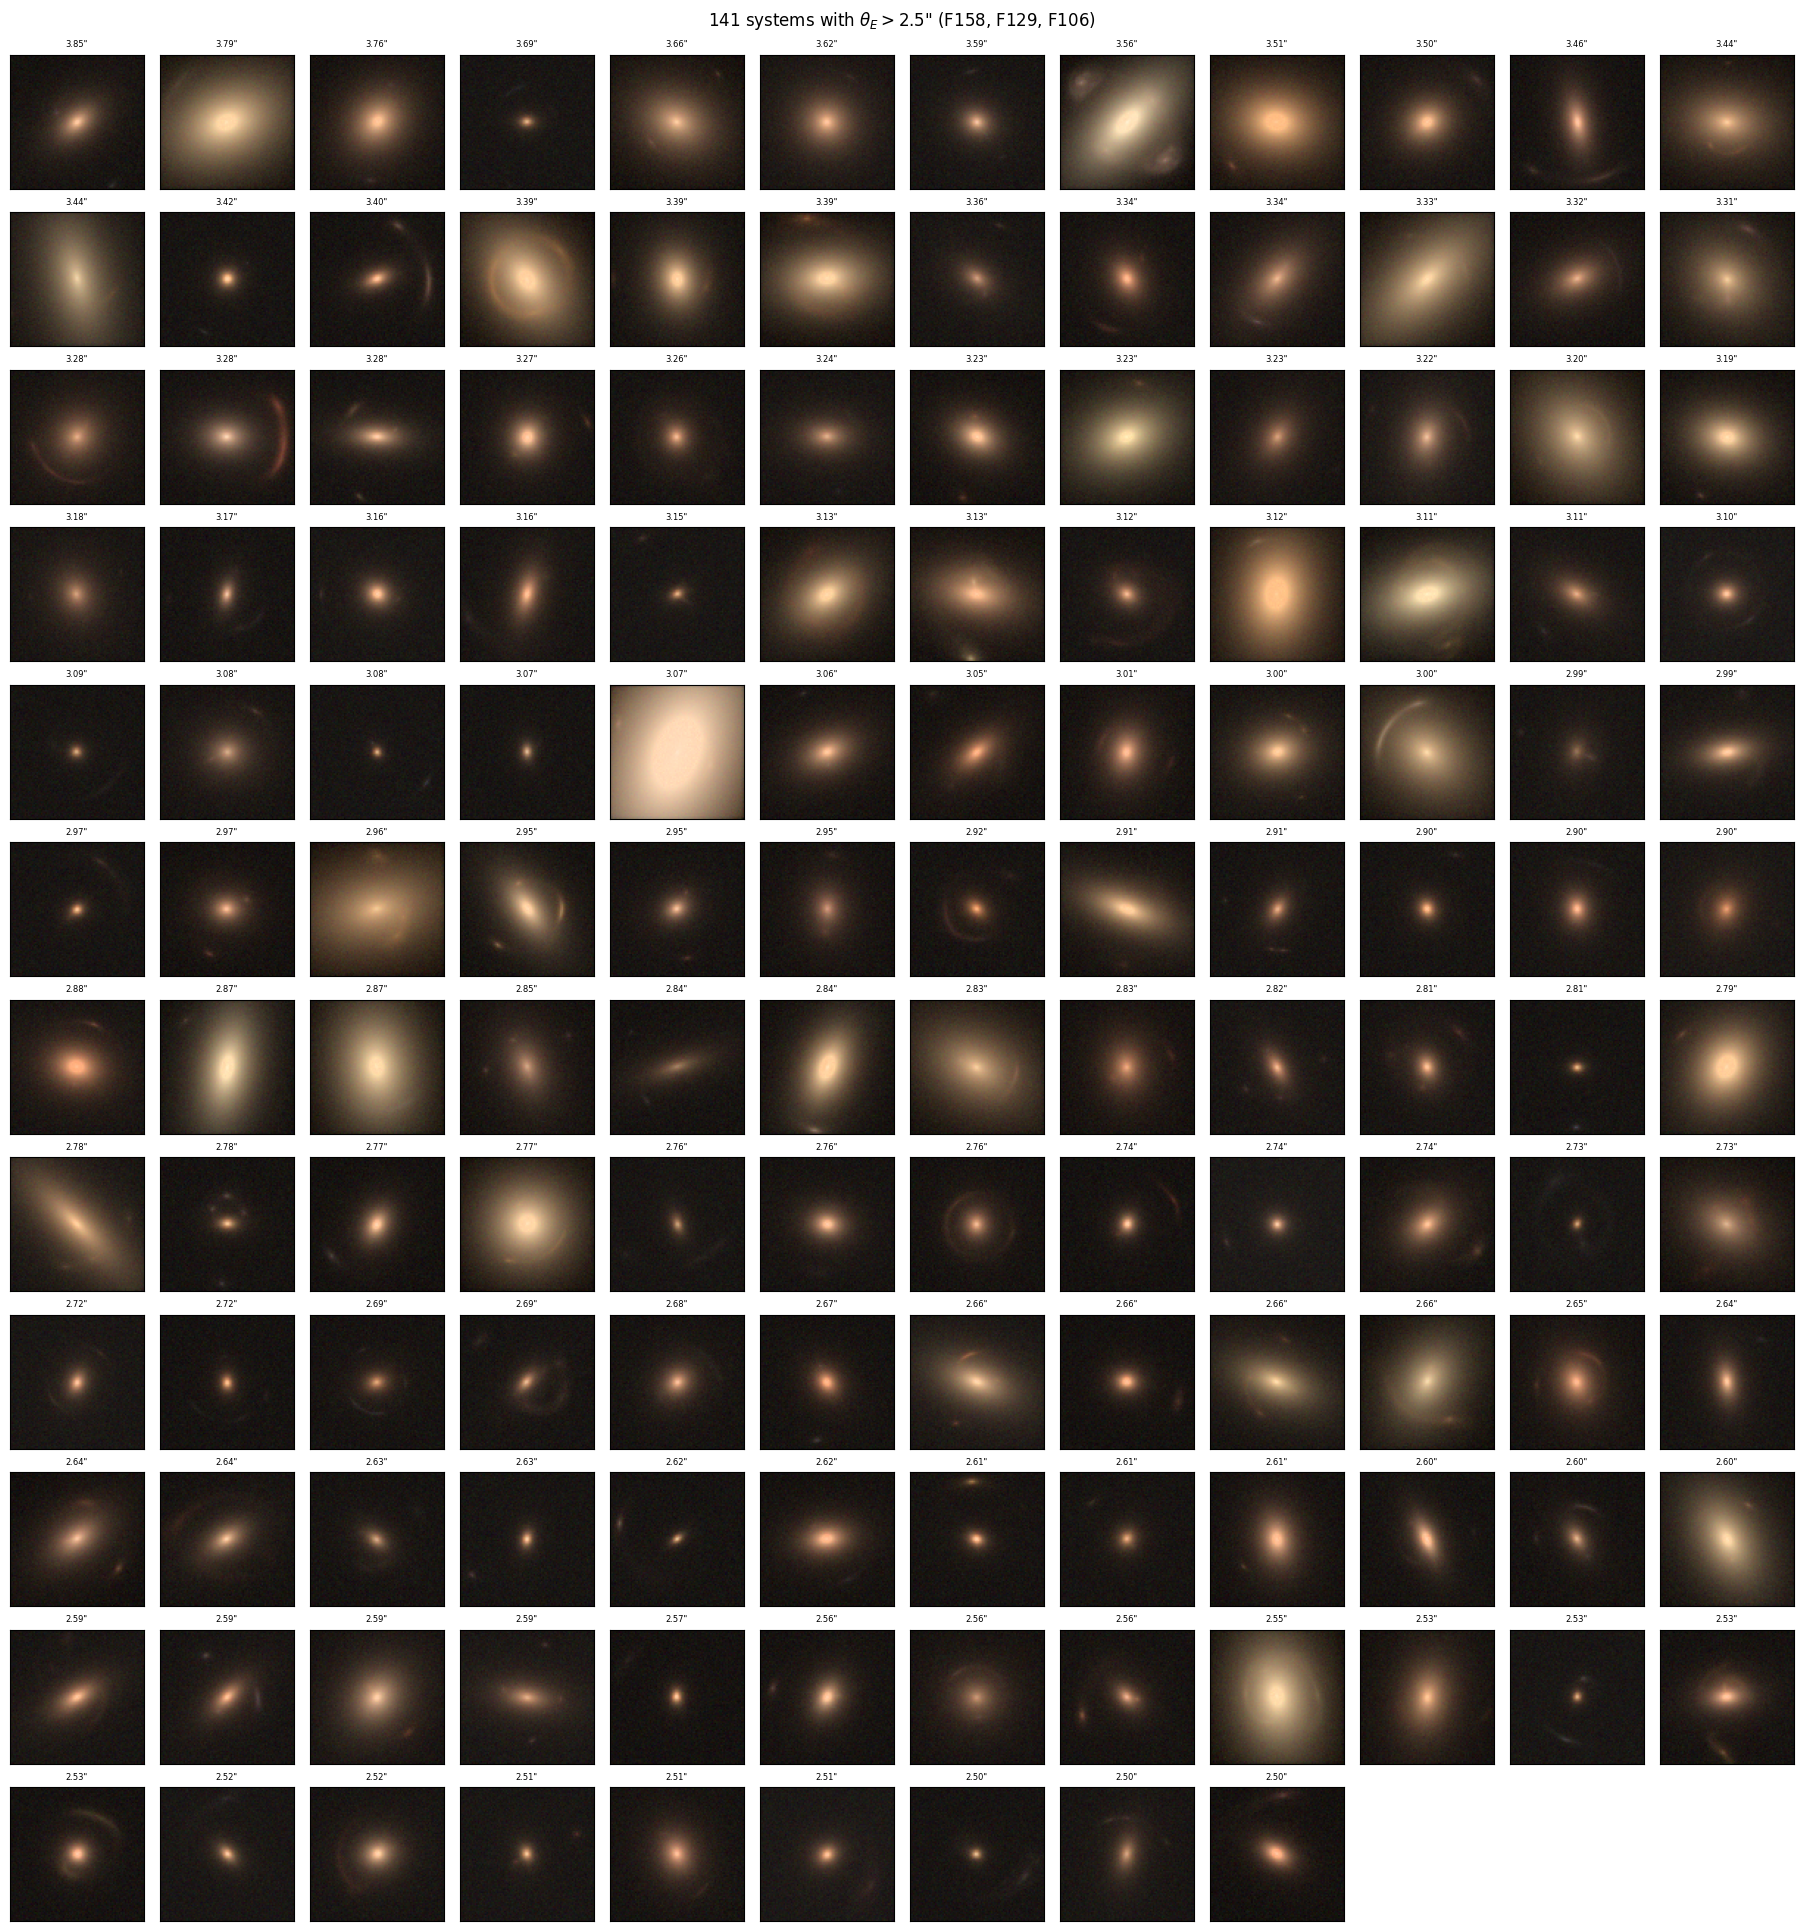

In [ ]:
ncols = 12
max_panels = None  # e.g. 100 to plot only the largest-theta_E systems

grid_uids = selected_uids if max_panels is None else selected_uids[:max_panels]
grid_theta_e = selected_theta_e if max_panels is None else selected_theta_e[:max_panels]
nrows = int(np.ceil(len(grid_uids) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 1.6 * nrows), constrained_layout=True, squeeze=False)
for ax, uid, radius in zip(axes.flat, grid_uids, grid_theta_e):
    ax.imshow(rgb_image(uid))
    ax.set_title(f'{radius:.2f}"', fontsize=6)

# blank any leftover panels
for ax in axes.flat[len(grid_uids):]:
    ax.set_visible(False)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'{len(grid_uids)} systems with ' + r'$\theta_E > $' + f'{theta_e_min}" ({", ".join(rgb_bands)})')

# os.makedirs('figures/06', exist_ok=True)
# plt.savefig(f'figures/06/rgb_grid_theta_e_gt_{theta_e_min}.png', dpi=300)
plt.show()

# Image positions vs. the field of view

The lens model isn't stored in the HDF5 file, so the image positions are recomputed by
solving the lens equation on the step-02 `StrongLens` objects the dataset was built from
(`GalaxyGalaxy.get_image_positions()` wraps lenstronomy's `LensEquationSolver`). Positions
come back in arcseconds relative to the center of the scene, which is also the center of
the cutout, so a system's images are inside the (square) field of view when both
coordinates are within `fov / 2`. These large-Einstein-radius systems are exactly the ones
whose images can land outside the cutout.

In [19]:
import pandas as pd

from mejiro.utils import util
from mejiro.utils.pipeline_helper import PipelineHelper

# the step-02 pickles embed mejiro-v2 astropy objects; the pipeline scripts apply this
# patch before unpickling, so mirror it here
PipelineHelper.patch_astropy_for_mejiro_v2_pickles()

lens_dir = '/data2/bwedig/mejiro/roman_data_challenge_rung_0/02'  # TODO update this path!
pipeline_label = 'roman_data_challenge_rung_0'
fov_band = rgb_bands[0]  # any band works: all bands share the same pixel grid

records = []
for uid, radius in zip(selected_uids, selected_theta_e):
    lens = util.unpickle(os.path.join(lens_dir, 'sca*', f'lens_{pipeline_label}_{uid}.pkl'))
    image_x, image_y = lens.get_image_positions()  # arcsec, relative to the center of the scene

    dataset = f['images'][f'strong_lens_{uid}'][f'exposure_{uid}_{fov_band}']
    fov = float(dataset.attrs['fov'][0])
    pixel_scale = float(dataset.attrs['pixel_scale'][0])
    num_pix = dataset.shape[0]

    # the scene is centered on (0, 0), so the FOV cut is a bound on |x| and |y|
    on_fov = (np.abs(image_x) <= fov / 2) & (np.abs(image_y) <= fov / 2)

    # lenstronomy's pixel convention, for overplotting on the cutouts
    x_pix = image_x / pixel_scale + (num_pix - 1) / 2
    y_pix = image_y / pixel_scale + (num_pix - 1) / 2

    records.append({
        'uid': uid,
        'theta_e': radius,
        'n_images': len(image_x),
        'n_on_fov': int(on_fov.sum()),
        'n_off_fov': int((~on_fov).sum()),
        'all_on_fov': bool(on_fov.all()) if len(image_x) > 0 else False,
        'max_offset': float(np.max(np.abs(np.concatenate([image_x, image_y])))) if len(image_x) > 0 else np.nan,
        'fov': fov,
        'image_x': image_x,
        'image_y': image_y,
        'x_pix': x_pix,
        'y_pix': y_pix,
        'on_fov': on_fov,
    })

image_positions = pd.DataFrame(records)

n_fully_on = int((image_positions['n_off_fov'] == 0).sum())
n_partial = int(((image_positions['n_off_fov'] > 0) & (image_positions['n_on_fov'] > 0)).sum())
n_fully_off = int((image_positions['n_on_fov'] == 0).sum())

print(f'{len(image_positions)} systems, {image_positions["n_images"].sum()} images total')
print(f'  all images on the FOV   : {n_fully_on}')
print(f'  some images off the FOV : {n_partial}')
print(f'  all images off the FOV  : {n_fully_off}')

image_positions[['uid', 'theta_e', 'n_images', 'n_on_fov', 'n_off_fov', 'all_on_fov', 'max_offset', 'fov']].head(20)

141 systems, 437 images total
  all images on the FOV   : 130
  some images off the FOV : 11
  all images off the FOV  : 0


,uid,theta_e,n_images,n_on_fov,n_off_fov,all_on_fov,max_offset,fov
0,00005626,3.853156,3,2,1,False,5.624197,10.01
1,00009737,3.786007,3,3,0,True,4.061541,10.01
2,00001880,3.755088,3,3,0,True,4.908470,10.01
3,00010100,3.689241,4,3,1,False,5.480911,10.01
4,00007924,3.655788,3,3,0,True,4.472509,10.01
5,00009043,3.615065,3,3,0,True,4.524525,10.01
6,00006732,3.591275,3,3,0,True,4.321552,10.01
7,00002763,3.563408,4,4,0,True,3.556196,10.01
8,00007868,3.512457,3,3,0,True,3.859051,10.01
9,00005661,3.502956,3,3,0,True,4.097507,10.01


## The systems with images off the field of view

Each cutout is drawn in angular coordinates with the axes extended past the edge of the
field of view, so the images that fall outside it are still visible. The dashed square is
the FOV boundary.

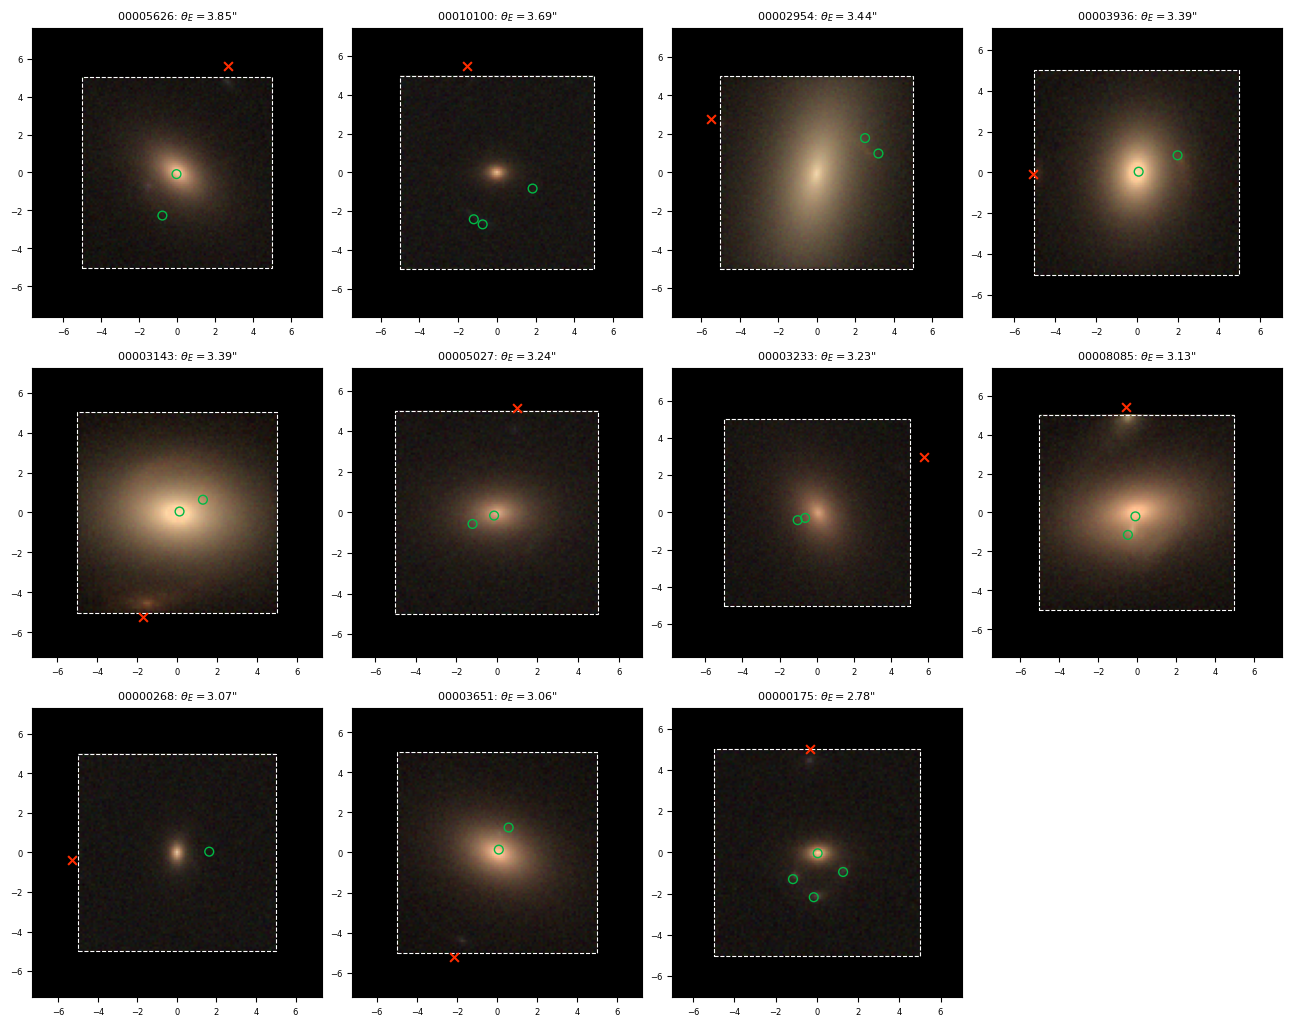

In [ ]:
from matplotlib.patches import Rectangle

partial = image_positions[(image_positions['n_off_fov'] > 0) & (image_positions['n_on_fov'] > 0)]
margin = 2.0  # arcsec of padding beyond the outermost image position

ncols_partial = 4
nrows_partial = int(np.ceil(len(partial) / ncols_partial))

fig, axes = plt.subplots(nrows_partial, ncols_partial, figsize=(3.2 * ncols_partial, 3.4 * nrows_partial),
                         constrained_layout=True, squeeze=False)
for ax, (_, row) in zip(axes.flat, partial.iterrows()):
    half_fov = row['fov'] / 2

    # origin='lower' so that the array's row index increases with angular y, which is the
    # convention the image positions are in
    ax.imshow(rgb_image(row['uid']), origin='lower',
              extent=[-half_fov, half_fov, -half_fov, half_fov])
    ax.add_patch(Rectangle((-half_fov, -half_fov), row['fov'], row['fov'],
                           fill=False, edgecolor='white', linestyle='--', linewidth=0.8))

    on = row['on_fov']
    ax.scatter(row['image_x'][on], row['image_y'][on], marker='o', s=40,
               facecolors='none', edgecolors='#00B945', label='on FOV')
    ax.scatter(row['image_x'][~on], row['image_y'][~on], marker='x', s=40,
               color='#FF2C00', label='off FOV')

    limit = max(np.max(np.abs(np.concatenate([row['image_x'], row['image_y']]))) + margin, half_fov + 0.25)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_facecolor('black')
    ax.set_title(f"{row['uid']}: " + r'$\theta_E = $' + f"{row['theta_e']:.2f}\"", fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes.flat[len(partial):]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='outside lower center', ncol=2)
# fig.suptitle('Systems with images outside the field of view [arcsec]')

# plt.savefig(f'figures/06/off_fov_image_positions_theta_e_gt_{theta_e_min}.png', dpi=300)
plt.show()

In [10]:
f.close()